In [1]:
from process_impl import config

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def plot_evaluation_metrics(evals_path):
    print(evals_path)
    data = np.load(evals_path)
    
    if 'timesteps' not in data or 'results' not in data:
        raise ValueError("O arquivo .npz deve conter 'timesteps' e 'results' (como salvo pelo EvalCallback)")

    timesteps = data['timesteps']
    results = data['results']  # shape: (n_evals, n_eval_episodes)

    # Média e desvio-padrão das recompensas
    mean_rewards = results.mean(axis=1)
    std_rewards = results.std(axis=1)

    # Encontrar índice onde o best model foi salvo
    best_idx = np.argmax(mean_rewards)
    best_mean_reward = mean_rewards[best_idx]
    best_timestep = timesteps[best_idx]
    best_std = std_rewards[best_idx]

    # Gráfico 1 – Curva de convergência com destaque no melhor modelo
    plt.figure(figsize=(8, 4))
    plt.plot(timesteps, mean_rewards, '.-', label='Mean Reward')
    plt.fill_between(timesteps, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.3, label='±1 std')
    plt.scatter([best_timestep], [best_mean_reward], color='red', zorder=5, label='Best Model')
    plt.annotate(
        f'Mean: {best_mean_reward:.2f}\nStd: {best_std:.2f}',
        xy=(best_timestep, best_mean_reward),
        xytext=(best_timestep, best_mean_reward + 0.05),
        textcoords='data',
        bbox=dict(boxstyle="round,pad=0.3", edgecolor='red', facecolor='white'),
        arrowprops=dict(arrowstyle='->', color='red')
    )
    plt.xlabel("Timesteps")
    plt.ylabel("Mean Reward")
    plt.title("Convergência do Treinamento (Recompensa Média por Avaliação)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Gráfico 2 – Histograma da MELHOR avaliação
    plt.figure(figsize=(6, 4))
    plt.hist(results[best_idx], bins=10, alpha=0.7, color='orange')
    plt.title(f"Distribuição das Recompensas na Melhor Avaliação (t={best_timestep})")
    plt.xlabel("Reward")
    plt.ylabel("Frequência")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Gráfico 3 – Boxplot com destaque na melhor avaliação
    plt.figure(figsize=(10, 4))
    plt.boxplot(results.T, positions=timesteps, widths=timesteps[1] - timesteps[0])
    plt.axvline(x=best_timestep, color='red', linestyle='--', label='Best Model')
    plt.title("Boxplot das Recompensas por Avaliação")
    plt.xlabel("Timesteps")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

   
    # Supondo que você já tenha essas variáveis definidas:
    # timesteps: vetor 1D com os steps (ex: np.arange(len(mean_rewards)))
    # mean_rewards: vetor 1D com as médias
    # std_rewards: vetor 1D com os desvios padrão
    
    # Área sombreada do desvio padrão
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=np.concatenate([timesteps, timesteps[::-1]])*3,
        y=np.concatenate([mean_rewards + std_rewards, (mean_rewards - std_rewards)[::-1]]),
        fill='toself',
        fillcolor='lightgray',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        showlegend=True,
        name='Reward Standard Deviation in Evaluation Simulations'
    ))
    
    # Linha da média
    fig.add_trace(go.Scatter(
        x=timesteps*3,
        y=mean_rewards,
        mode='lines',
        name='Mean Reward in Evaluation Simulations',
        line=dict(color='black', width=5)
    ))
        
    fig.update_layout(
        xaxis=dict(
            title=dict(
                text='Total learning steps',
                font=dict(size=20)
            ),
            tickfont=dict(size=16)
        ),
        yaxis=dict(
            title=dict(
                text='Sum of Rewards',
                font=dict(size=20)
            ),
            tickfont=dict(size=16)
        ),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=-0.65,
            xanchor="center",
            x=0.5,
            font=dict(size=16)
        ),
        height=400,
        width=800
    )

    
    # Mostrar o gráfico
    fig.show()
    # Salvar como PNG com alta resolução
    fig.write_image("conv.png", format="png", width=800, height=400, scale=6, engine="kaleido")


In [3]:
cd = "C:\\Users\\Douglas\\Desktop\\codigos_mestrado9_aws_ph_forcle\\src\\models_\\best_model_ferm_37_reward_params_3.7_2.86_59.31_-0.43_35.42_-0.75_0.45_21.02__3_"


C:\Users\Douglas\Desktop\codigos_mestrado9_aws_ph_forcle\src\models_\best_model_ferm_37_reward_params_3.7_2.86_59.31_-0.43_35.42_-0.75_0.45_21.02__0_\evaluations.npz


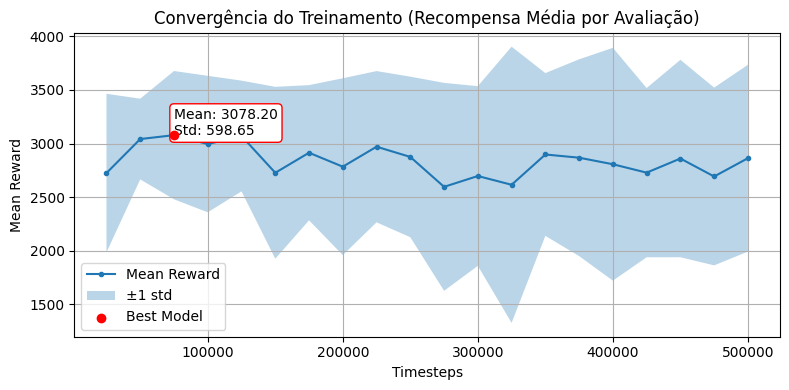

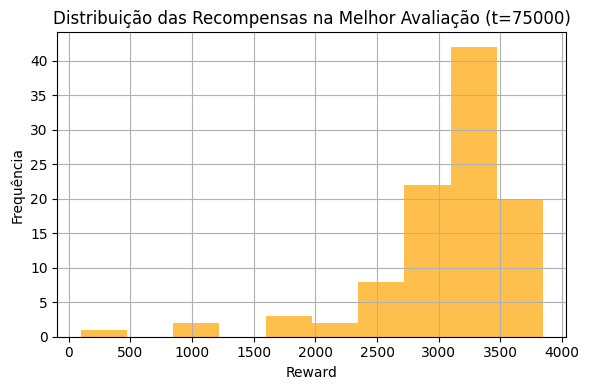

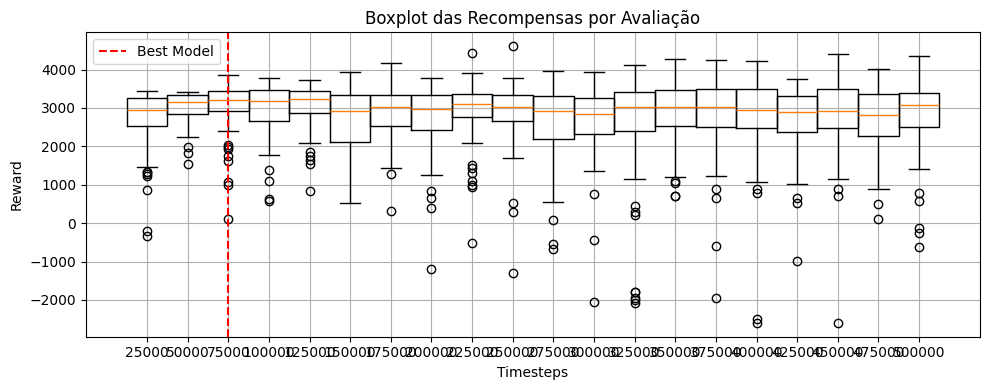

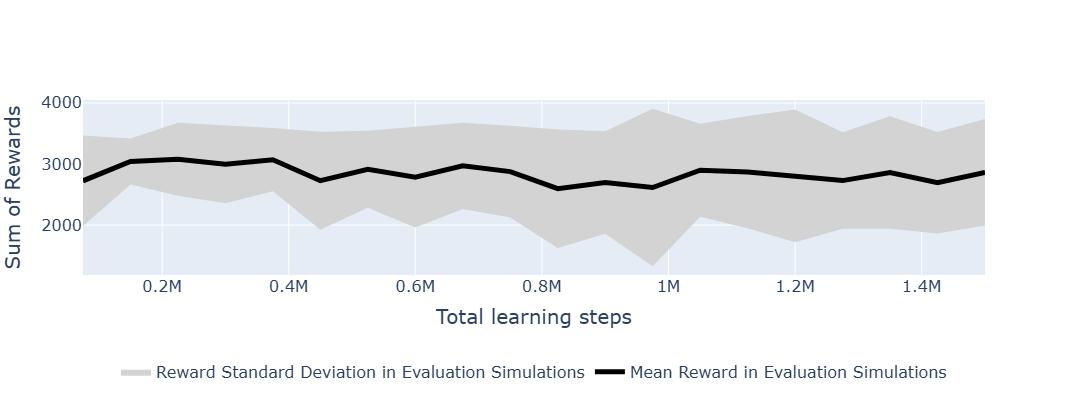

C:\Users\Douglas\AppData\Local\Temp\ipykernel_88224\728759529.py:128: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




C:\Users\Douglas\Desktop\codigos_mestrado9_aws_ph_forcle\src\models_\best_model_ferm_37_reward_params_3.7_2.86_59.31_-0.43_35.42_-0.75_0.45_21.02__1_\evaluations.npz


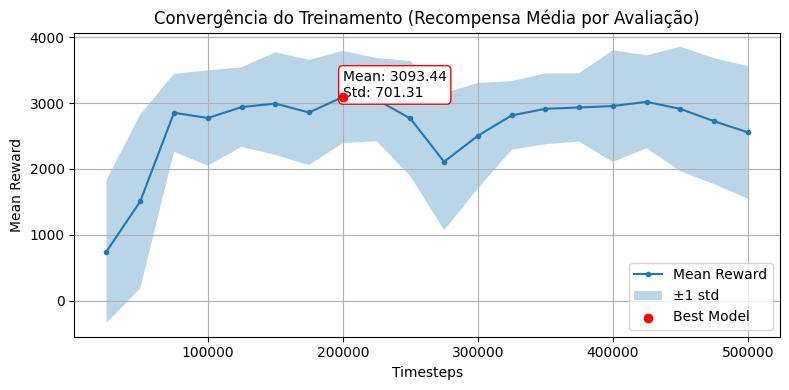

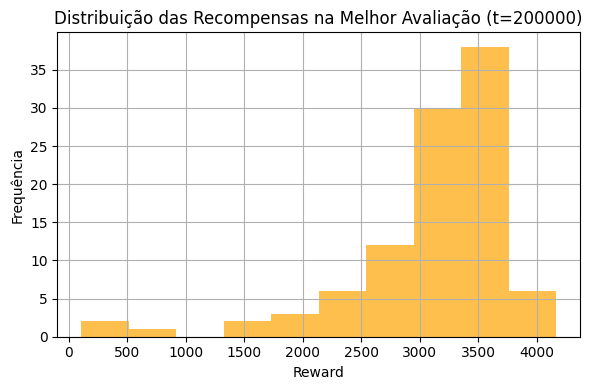

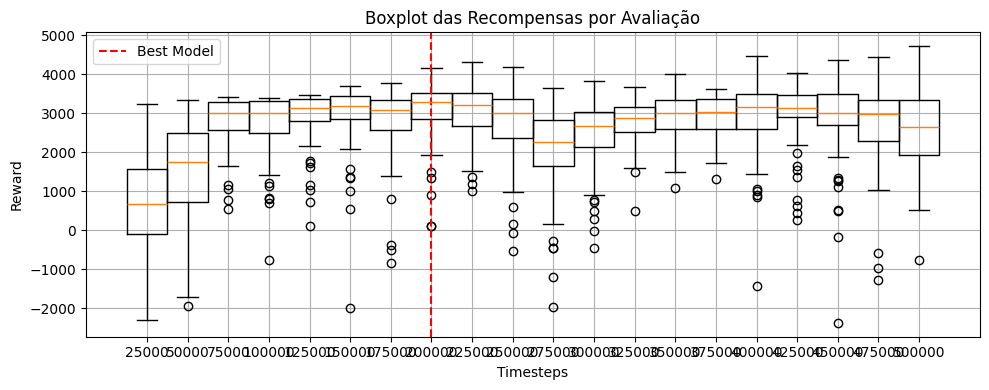

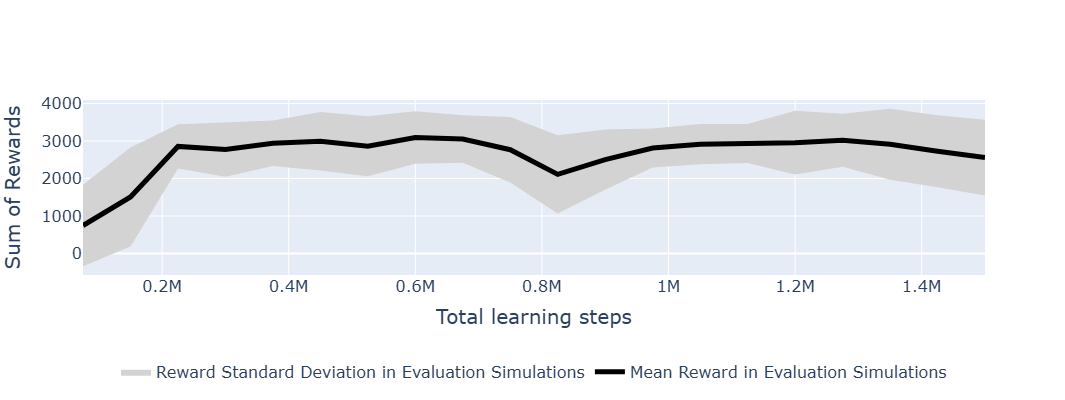

C:\Users\Douglas\AppData\Local\Temp\ipykernel_88224\728759529.py:128: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




C:\Users\Douglas\Desktop\codigos_mestrado9_aws_ph_forcle\src\models_\best_model_ferm_37_reward_params_3.7_2.86_59.31_-0.43_35.42_-0.75_0.45_21.02__2_\evaluations.npz


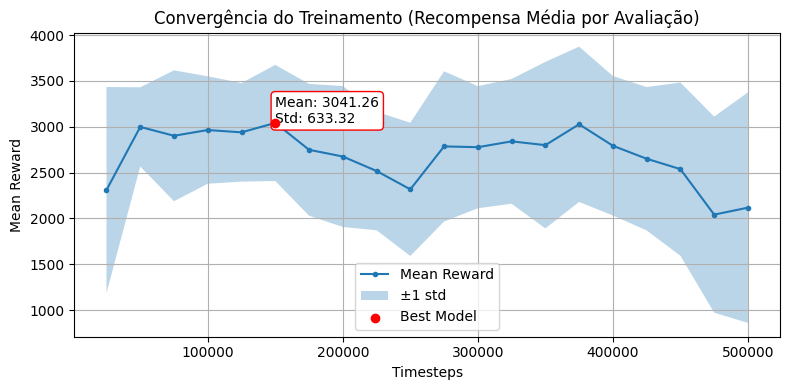

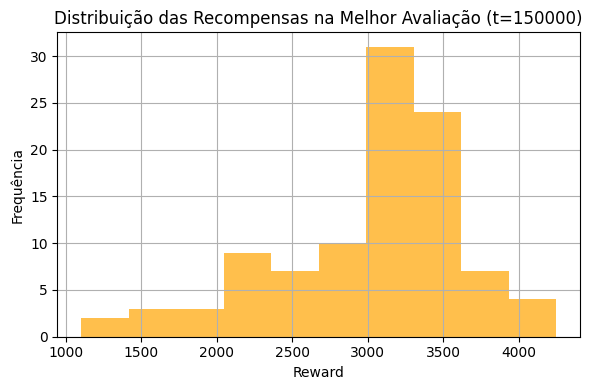

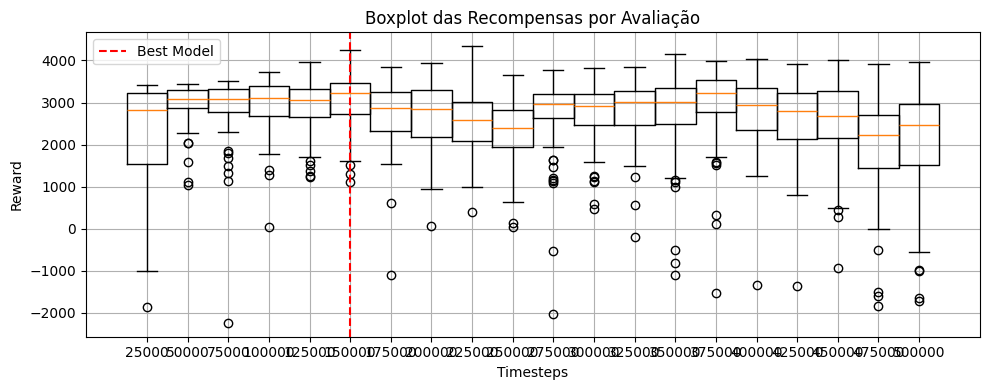

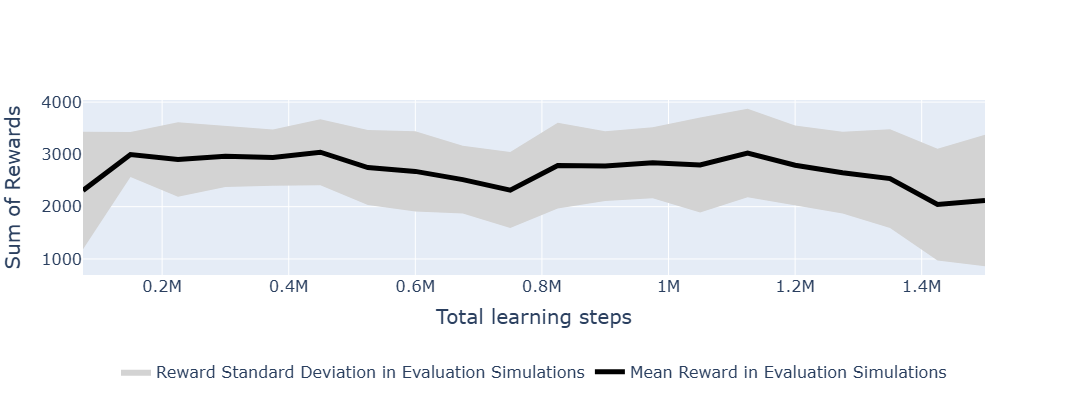

C:\Users\Douglas\AppData\Local\Temp\ipykernel_88224\728759529.py:128: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




C:\Users\Douglas\Desktop\codigos_mestrado9_aws_ph_forcle\src\models_\best_model_ferm_37_reward_params_3.7_2.86_59.31_-0.43_35.42_-0.75_0.45_21.02__3_\evaluations.npz


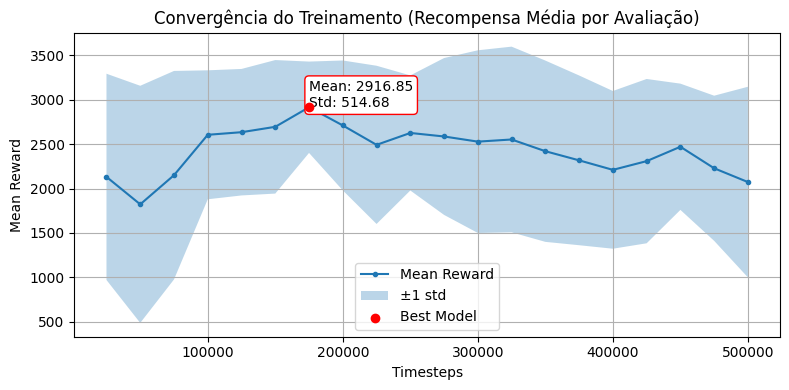

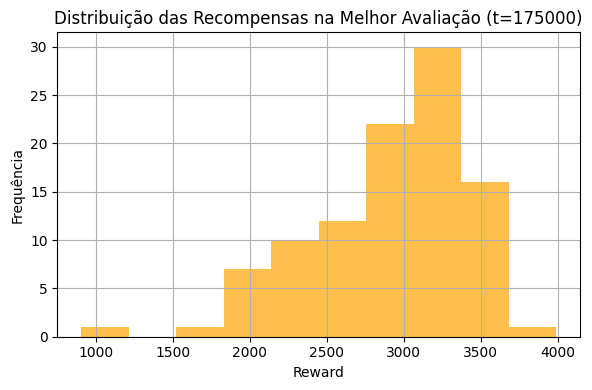

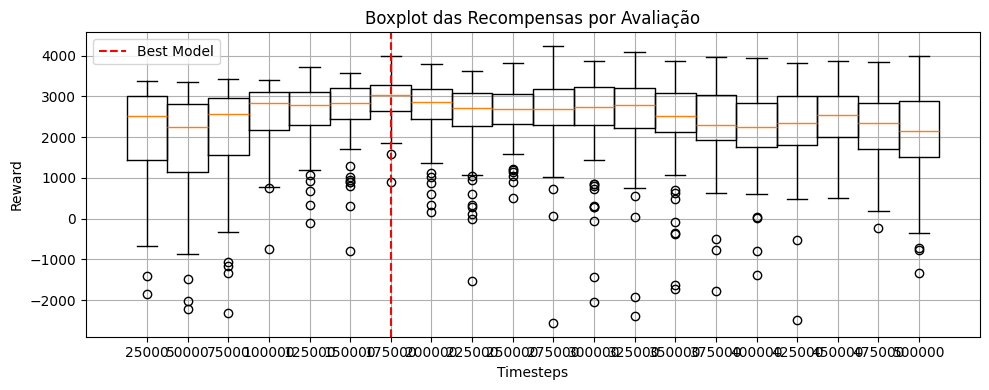

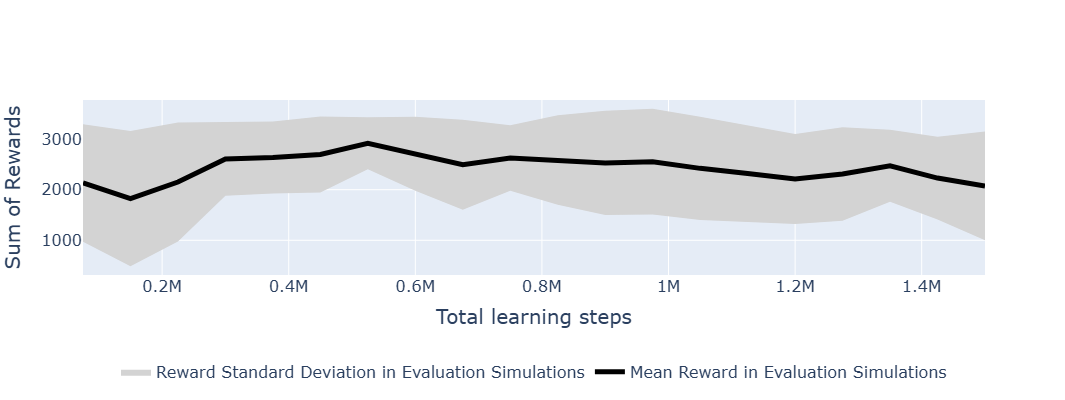

C:\Users\Douglas\AppData\Local\Temp\ipykernel_88224\728759529.py:128: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




In [4]:
plot_evaluation_metrics(cd[:-2]+"0_" + "\\evaluations.npz")
plot_evaluation_metrics(cd[:-2]+"1_" + "\\evaluations.npz")
plot_evaluation_metrics(cd[:-2]+"2_" + "\\evaluations.npz")
plot_evaluation_metrics(cd[:-2]+"3_" + "\\evaluations.npz")


Running evaluation for variable: h1
  → Changing h1 to 8.5
  → Changing h1 to 10.0
{'h3': [0.9146126288412244, 0.9102070258910719, 0.9046275572887472, 0.8978803980339991, 0.889971720744388, 0.8809077015335716, 0.8706945256392713, 0.8593383932577499, 0.8468455254694527, 0.8332221702850295, 0.81847460891374, 0.8026091620723745, 0.7856321966555655, 0.7675501326615608, 0.7483694507708651, 0.7292932904690392, 0.7103217701672138, 0.6914548898653885, 0.6726926495635628, 0.6540350492617373, 0.635482088959912, 0.6170337686580865, 0.5986900883562607, 0.5804510480544354, 0.56231664775261, 0.5442868874507847, 0.5263617671489593, 0.508541286847134, 0.49082544654530835, 0.47321424624348274, 0.45570768594165734, 0.4383057656398315, 0.42100848533800606, 0.4038158450361806, 0.3867426133709524, 0.36987845281961373, 0.3532816848222311, 0.3369966914909963, 0.32107139848206634, 0.3055866299916279, 0.2905946784817588, 0.2761488990843053, 0.26229625903933695, 0.2490774355371821, 0.23652701038411017, 0.22466

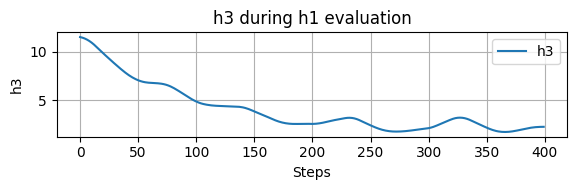

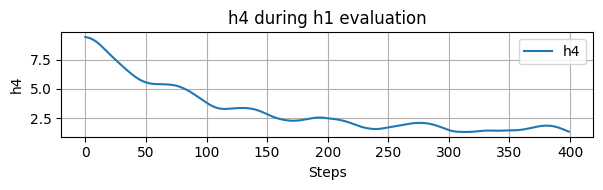

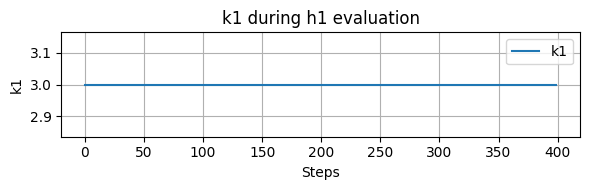

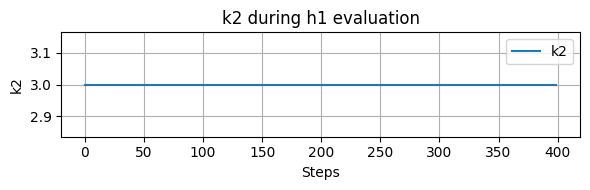

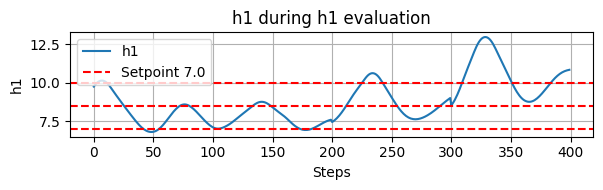

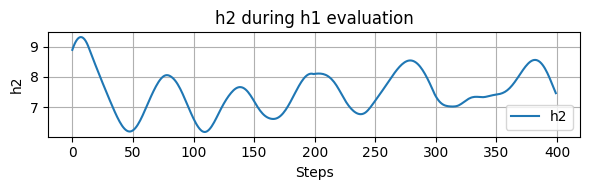

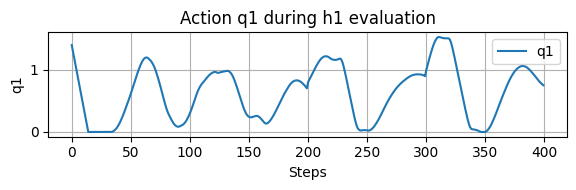

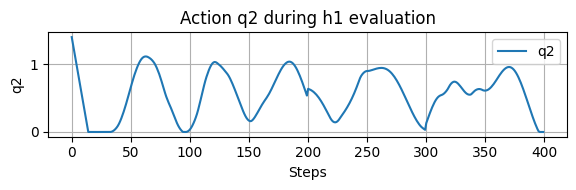

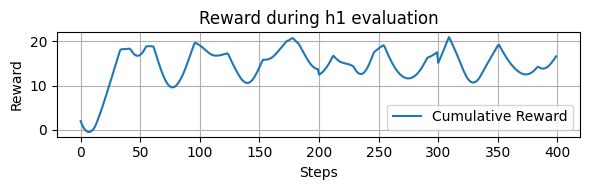


Running evaluation for variable: h2
  → Changing h2 to 8.5
  → Changing h2 to 10.0
{'h3': [0.23858637765874757, 0.24035420175170796, 0.2424833623305529, 0.24492985400545986, 0.24764788236765112, 0.250494985271305, 0.2532799943252102, 0.25581500908202504, 0.2579259507351279, 0.2594509094451587, 0.260284825932912, 0.26021358157544916, 0.25908940160124017, 0.25683326276248075, 0.25342080554743895, 0.24884704987324224, 0.24311403236447315, 0.2362267163839855, 0.22819140909212554, 0.21901511810945018, 0.2087052916343508, 0.19726974185302226, 0.18471669257065204, 0.17105420928780846, 0.15629060254557592, 0.14078694307462203, 0.12538792360366835, 0.11009354413271466, 0.09490380466176074, 0.0798187051908068, 0.06483824571985308, 0.04996242624889913, 0.035191246777945384, 0.020524707306991408, 0.005962807836037642, -0.008494451634916023, -0.02284707110587003, -0.03709505057682383, -0.05123839004777764, -0.06527708951873157, -0.0792111489896854, -0.09304056846063913, -0.10676534793159298, -0.12

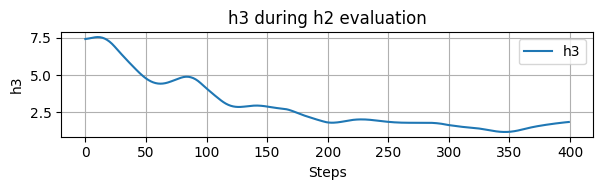

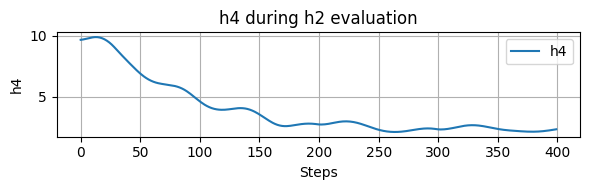

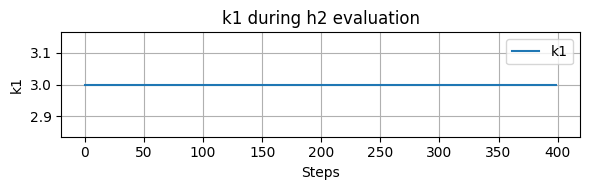

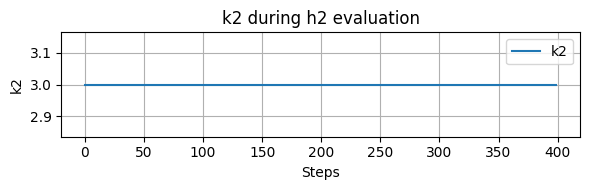

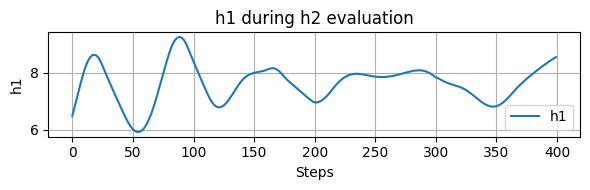

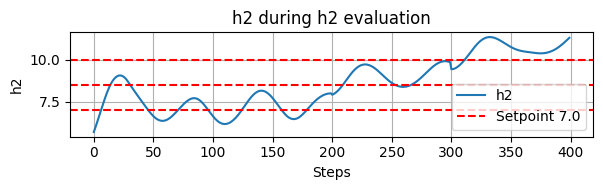

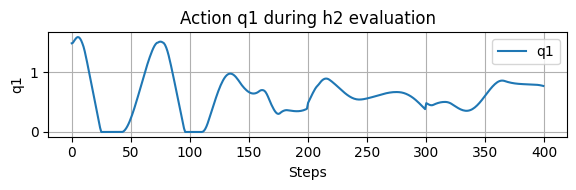

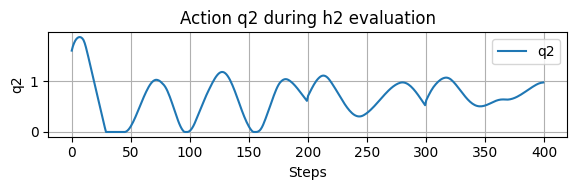

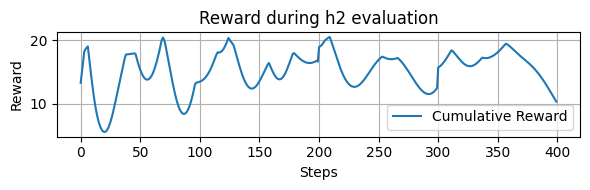


Running evaluation for variable: h3
  → Changing h3 to 9
  → Changing h3 to 12
{'h3': [0.1802154499256725, 0.18123599343076968, 0.18138602355717315, 0.1805878299273307, 0.17883128845214702, 0.17616332863029638, 0.17252090385793362, 0.1678562609564791, 0.16212720583491524, 0.1553062811062571, 0.1473823559384917, 0.1383531492777037, 0.12822164378336365, 0.11699451390102333, 0.10468175859160023, 0.09129960631309264, 0.07687460141656333, 0.0619146492173106, 0.04705933701805787, 0.03230866481880512, 0.017662632619552365, 0.003121240420299598, -0.011315511778953069, -0.025647623978205747, -0.03987509617745866, -0.05399792837671147, -0.06801612057596429, -0.08192967277521701, -0.09573858497446963, -0.10944285717372226, -0.1230424893729749, -0.13645842280910536, -0.14959246272673454, -0.16235083322470667, -0.17464549362395942, -0.18639550301076602, -0.19752832650470686, -0.2079805484775189, -0.21769805264893238, -0.22663579110521714, -0.234756821526651, -0.24202863534396757, -0.24842635589899

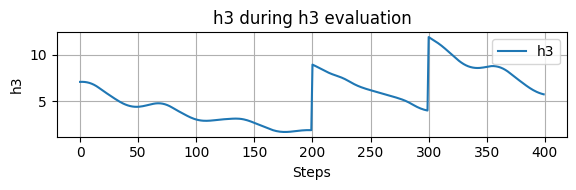

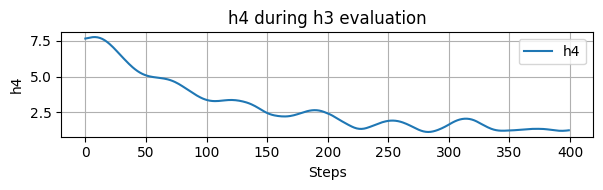

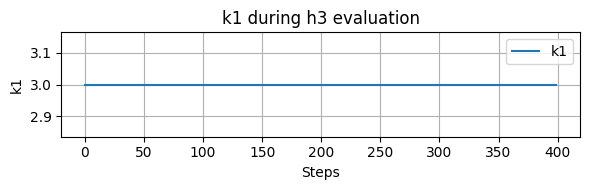

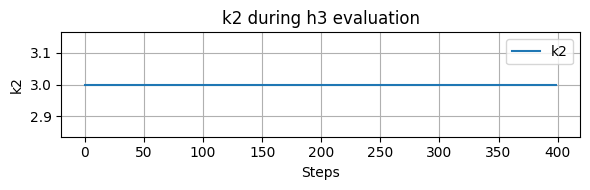

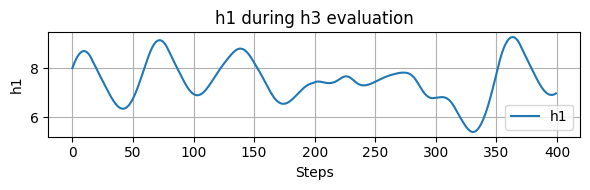

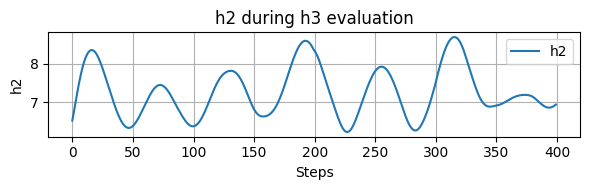

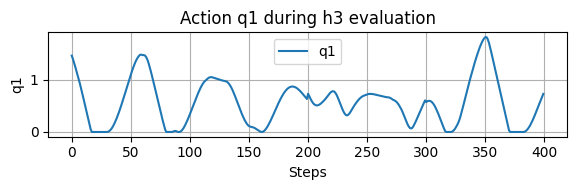

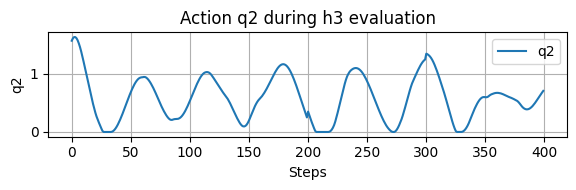

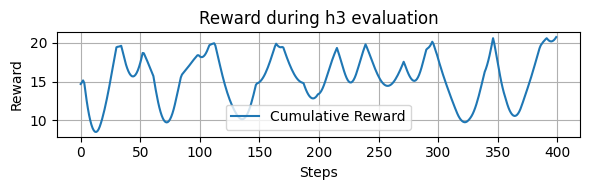


Running evaluation for variable: h4
  → Changing h4 to 9
  → Changing h4 to 12
{'h3': [0.7772627541071806, 0.778373748543393, 0.7806752849836309, 0.7841604743939785, 0.7888211991037037, 0.7934601478662773, 0.798074108373265, 0.8026632470497825, 0.807227728791398, 0.8117677169842723, 0.8161718999805461, 0.8202284505318751, 0.8237497432939305, 0.8265569112701823, 0.8283810925097346, 0.8290916747833317, 0.8286347813196409, 0.8269994093123165, 0.8241851972713101, 0.8201946232780675, 0.8150319893352351, 0.8087020212191016, 0.8012103086886373, 0.7925628191654484, 0.7827657064020555, 0.7718252293373646, 0.7597477266541348, 0.7465396161707423, 0.7322074084814305, 0.7167577448598841, 0.700197480726042, 0.682533874369968, 0.6638213152275876, 0.6452133960852073, 0.6267101169428269, 0.6083114778004466, 0.5900174786580659, 0.5718281195156854, 0.553743400373305, 0.5357633212309247, 0.5178878820885442, 0.5001170829461639, 0.4824509238037835, 0.4648894046614027, 0.44743252551902235, 0.430080286376642

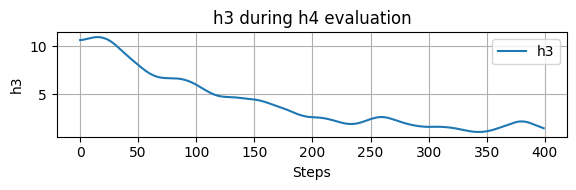

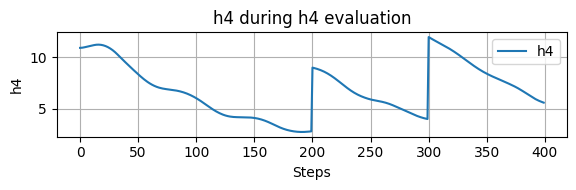

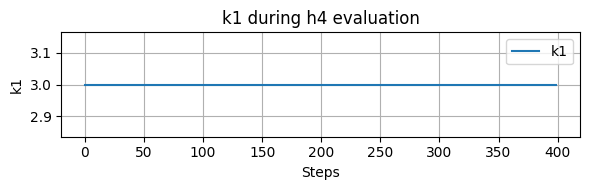

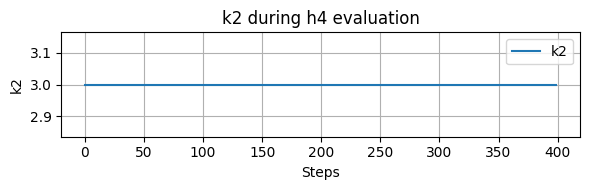

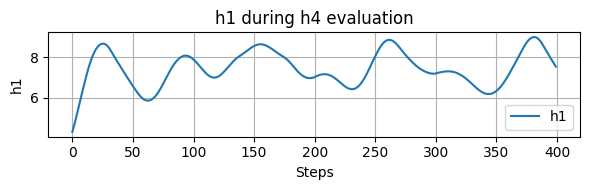

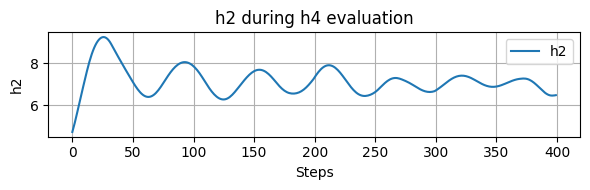

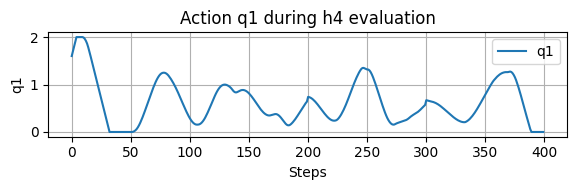

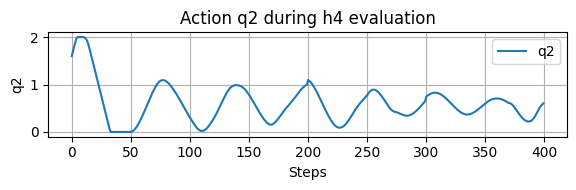

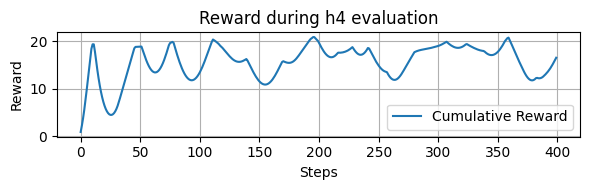


Running evaluation for variable: k1
  → Changing k1 to 2
  → Changing k1 to 4
{'h3': [0.4575252695172669, 0.4556661247277225, 0.4526217082803703, 0.44839911965767687, 0.4430054467057074, 0.43644777221223374, 0.4287331815571729, 0.41986877091154917, 0.4098616560359545, 0.39871898108933723, 0.38644792822018714, 0.37305572749894345, 0.35854966818396417, 0.342937111813888, 0.32622550740911205, 0.3096179212211836, 0.2931149750332551, 0.27671666884532686, 0.2604230026573984, 0.24423397646946965, 0.22814959028154114, 0.21216984409361261, 0.1962947379056843, 0.18052427171775576, 0.16485844552982742, 0.14929725934189908, 0.1338407131539705, 0.11848880696604192, 0.10324154077811332, 0.08809891459018471, 0.07306092840225631, 0.0581275822143279, 0.04329887602639926, 0.028603157879338204, 0.01412742546000767, -4.224837213795407e-05, -0.013822559712380333, -0.027134760627985144, -0.039906141495490766, -0.052071112652376184, -0.06357186022433814, -0.07435860896889601, -0.0843895728326024, -0.0936306

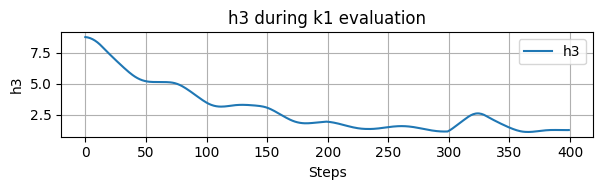

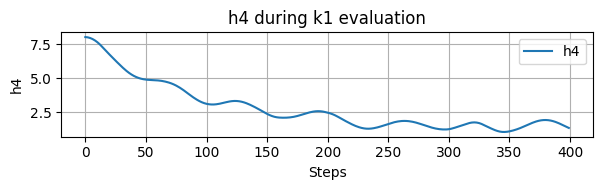

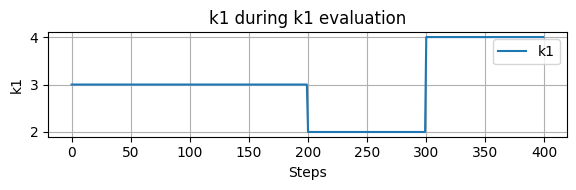

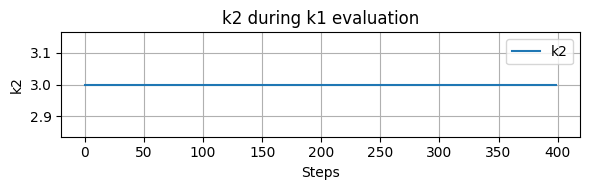

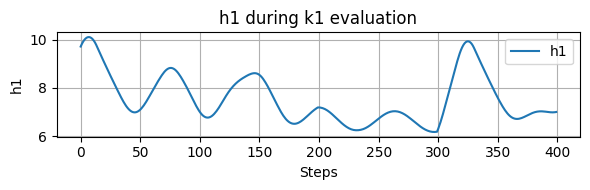

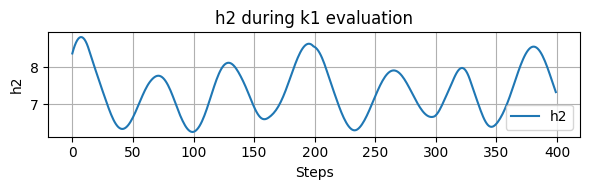

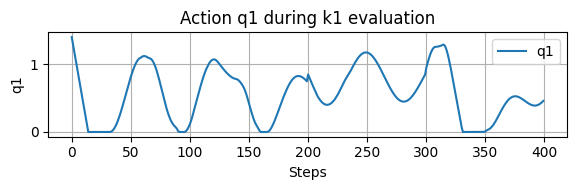

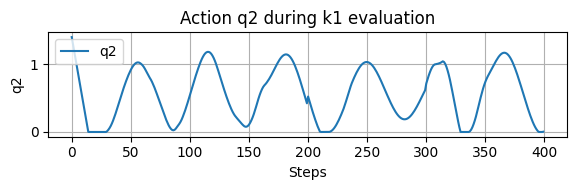

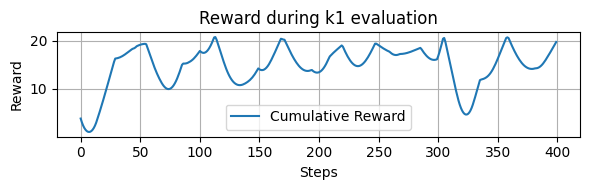


Running evaluation for variable: k2
  → Changing k2 to 2
  → Changing k2 to 4
{'h3': [0.9431150367025956, 0.9385702194775298, 0.9328529795893552, 0.9259691484820751, 0.9179247026763939, 0.9087256792283434, 0.8983781093845662, 0.8868880934278247, 0.8742617854352155, 0.8605054121477662, 0.8456253196653363, 0.8296279983397847, 0.8125202137705976, 0.7943092949299035, 0.7750038518424451, 0.755782542030871, 0.7366658722192974, 0.7176538424077235, 0.6987464525961498, 0.679943702784576, 0.6612455929730023, 0.6426521231614284, 0.6241632933498547, 0.6057791035382809, 0.5874995537267071, 0.5693246439151334, 0.5512543741035596, 0.5333516704129133, 0.5156845792498412, 0.49832068934120666, 0.4813259657692184, 0.4647636567262461, 0.4486926519072467, 0.4331675009794098, 0.41823798928213307, 0.4039438784099494, 0.3903430444637819, 0.3774843810157762, 0.36539393087983085, 0.3540717114831773, 0.3435111690870729, 0.3336992446260123, 0.3246163302022216, 0.3162361276014207, 0.3085254463737781, 0.3014439782

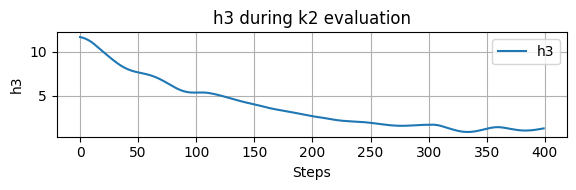

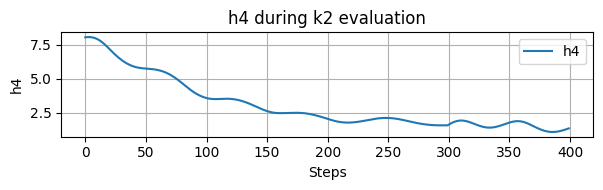

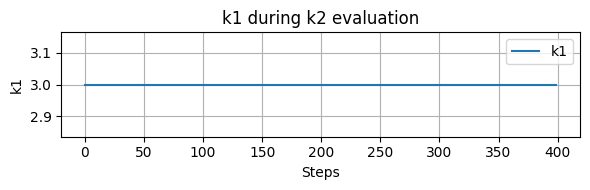

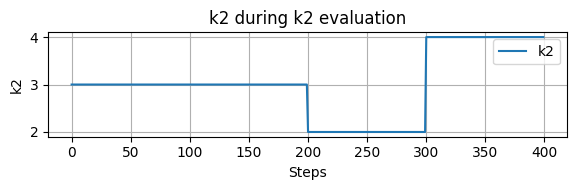

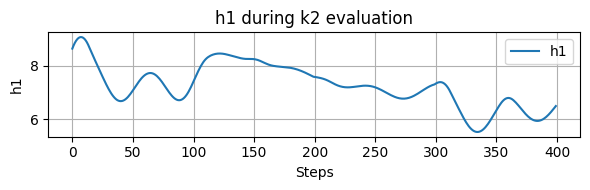

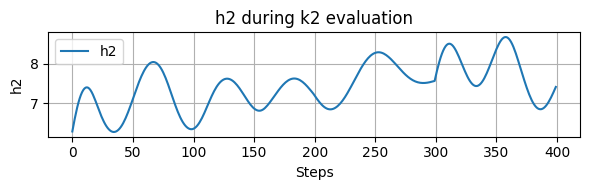

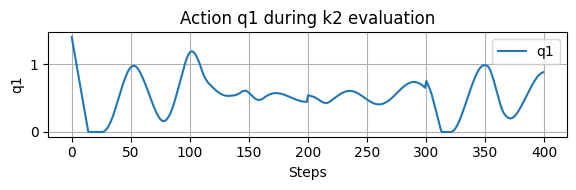

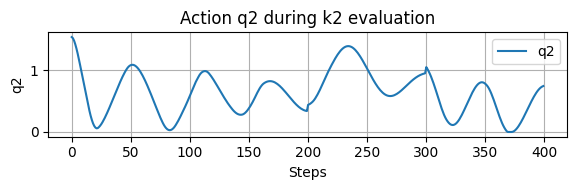

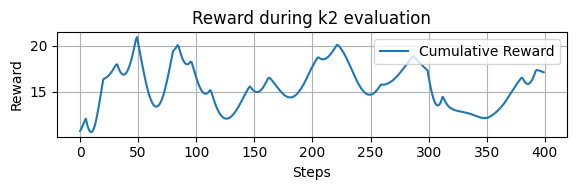

In [5]:
import sys
import os

# Caminho relativo a partir do notebook
sys.path.append(os.path.abspath(os.path.join("..", "..", "src")))

from eval_env_runner import EvaluationEnvRunner
cd = cd[:-2]+"1_"


runner = EvaluationEnvRunner(config, model_dir=cd)
runner.run_evaluations()


In [6]:
a=[1,2,3,2,1,2,23]

In [7]:
l = len(a)
a[int(l/3):] = [10]*int(l/2)

In [8]:
a

[1, 2, 10, 10, 10]

In [9]:
sum([i['IAE_total'] for i in lista_dict])

NameError: name 'lista_dict' is not defined

In [ ]:
[i['IAE_total'] for i in lista_dict]